# Module 12: The Ideal 1-9 Lineup

Standard sabermetric lineup construction says: best OBP leads off, best overall hitter bats second, protect the 3-4 hitters. That's a starting point, not an endpoint.

This notebook builds a **data-driven lineup position model** using 2021-2025 FanGraphs data from the best teams in baseball. For each spot 1-9, we define measurable thresholds — then map the 2025 Yankees to the model and see where they fit and where they don't.

The goal: go beyond "sort by wOBA" and build lineup positions that account for **OBP + power + speed + contact + handedness** at every spot.

In [1]:
import sys
sys.path.insert(0, "../src")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
import seaborn as sns
from scipy.optimize import linear_sum_assignment

from fire_fishman.data.statcast import get_batting_stats

sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams["figure.figsize"] = (14, 8)

/Users/wks/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
# Load 2021-2025 FanGraphs batting stats
batting_dfs = []
for year in range(2021, 2026):
    df = get_batting_stats(year)
    df["Season"] = year
    batting_dfs.append(df)

batting = pd.concat(batting_dfs, ignore_index=True)
qualified = batting[batting["PA"] >= 300].copy()
print(f"Total qualified player-seasons (300+ PA): {len(qualified)}")

# Detect column names
barrel_col = next((c for c in ["Barrel%", "Barrel"] if c in qualified.columns),
                  next((c for c in qualified.columns if "barrel" in c.lower()), None))
k_col = "K%" if "K%" in qualified.columns else "SO%"
bb_col = "BB%" if "BB%" in qualified.columns else None
bsr_col = "BsR" if "BsR" in qualified.columns else None
spd_col = "Spd" if "Spd" in qualified.columns else None

# Normalize percentage columns to 0-1 if needed
for col in [k_col, bb_col, barrel_col]:
    if col and col in qualified.columns:
        qualified[col] = pd.to_numeric(qualified[col], errors="coerce")
        if qualified[col].median() > 1:
            qualified[col] = qualified[col] / 100

# Ensure numeric for key columns
for col in ["wOBA", "OBP", "SLG", "ISO", "wRC+", "AVG"]:
    if col in qualified.columns:
        qualified[col] = pd.to_numeric(qualified[col], errors="coerce")

print(f"Columns available: barrel={barrel_col}, K={k_col}, BB={bb_col}, BsR={bsr_col}, Spd={spd_col}")

Pulling FanGraphs batting stats for 2025...


Cached 537 player-seasons to /Users/wks/Documents/Projects/fire_fishman/notebooks/../src/fire_fishman/data/cache/batting_stats_2025.parquet
Total qualified player-seasons (300+ PA): 1395
Columns available: barrel=Barrel%, K=K%, BB=BB%, BsR=BsR, Spd=Spd


## Part 1: What Do the Best Teams Actually Do?

Before prescribing the ideal lineup, let's see what contenders actually look like. We'll identify the top offensive teams each year (top 5 by wRC+) and profile their hitters by production tier.

This is the empirical foundation — don't just assert what a lineup should look like, **measure** what winning lineups actually look like.

In [3]:
# Identify top offensive teams each year by average wRC+ of qualified hitters
team_offense = qualified.groupby(["Season", "Team"]).agg(
    avg_wRC=pd.NamedAgg(column="wRC+", aggfunc="mean"),
    avg_wOBA=pd.NamedAgg(column="wOBA", aggfunc="mean"),
    n_qualified=pd.NamedAgg(column="Name", aggfunc="count"),
).reset_index()

# Top 5 offensive teams per year
top_offenses = []
for year in qualified["Season"].unique():
    yr = team_offense[team_offense["Season"] == year].nlargest(5, "avg_wRC")
    top_offenses.append(yr)
top_offenses = pd.concat(top_offenses)

# Get all qualified hitters from top offensive teams
contender_hitters = qualified.merge(
    top_offenses[["Season", "Team"]], on=["Season", "Team"]
)

print(f"Top-5 offensive teams per year: {len(top_offenses)} team-seasons")
print(f"Qualified hitters on those teams: {len(contender_hitters)}")
print(f"\nTop offensive teams by year:")
for year in sorted(top_offenses["Season"].unique()):
    teams = top_offenses[top_offenses["Season"] == year]["Team"].tolist()
    print(f"  {year}: {', '.join(teams)}")

Top-5 offensive teams per year: 25 team-seasons
Qualified hitters on those teams: 212

Top offensive teams by year:
  2021: TOR, SFG, ATL, CHW, HOU
  2022: STL, HOU, NYM, LAD, ATL
  2023: ATL, TEX, LAA, TBR, SEA
  2024: LAD, HOU, NYY, BAL, SDP
  2025: SEA, NYY, ARI, LAD, ATH


In [4]:
# Profile what contending teams carry at each production tier
# Rank hitters within each team-season by wOBA
contender_hitters = contender_hitters.sort_values(
    ["Season", "Team", "wOBA"], ascending=[True, True, False]
)
contender_hitters["team_rank"] = contender_hitters.groupby(
    ["Season", "Team"]
).cumcount() + 1

# What does each "slot" look like on contending teams?
print("CONTENDER LINEUP SLOT PROFILES (avg of top-5 offensive teams, 2021-2025)")
print("=" * 80)
print(f"{'Rank':<6} {'wOBA':>6} {'OBP':>6} {'SLG':>6} {'ISO':>6} "
      f"{'K%':>6} {'BB%':>6} {'BsR':>6} {'Barrel%':>8} {'n':>4}")
print("-" * 80)

for rank in range(1, 10):
    slot = contender_hitters[contender_hitters["team_rank"] == rank]
    if len(slot) == 0:
        continue
    print(f"  #{rank:<4} {slot['wOBA'].mean():>6.3f} {slot['OBP'].mean():>6.3f} "
          f"{slot['SLG'].mean():>6.3f} "
          f"{slot['ISO'].mean():>6.3f} " if 'ISO' in slot.columns else "",
          f"{slot[k_col].mean():>5.1%} {slot[bb_col].mean():>5.1%} " if bb_col else "",
          f"{slot[bsr_col].mean():>6.1f} " if bsr_col and bsr_col in slot.columns else "",
          f"{slot[barrel_col].mean():>7.1%} " if barrel_col else "",
          f"{len(slot):>4}")

CONTENDER LINEUP SLOT PROFILES (avg of top-5 offensive teams, 2021-2025)
Rank     wOBA    OBP    SLG    ISO     K%    BB%    BsR  Barrel%    n
--------------------------------------------------------------------------------
  #1     0.408  0.394  0.576  0.281  20.4% 13.1%     0.2    15.6%    25
  #2     0.374  0.360  0.517  0.240  20.1% 10.4%    -0.2    12.1%    25
  #3     0.357  0.348  0.484  0.207  20.4%  8.9%     0.0    10.6%    25
  #4     0.347  0.340  0.466  0.203  22.3%  9.3%     0.4    10.8%    25
  #5     0.335  0.335  0.439  0.170  19.0%  8.3%    -0.7     7.7%    25
  #6     0.322  0.324  0.418  0.158  20.0%  7.7%    -0.2     7.8%    24
  #7     0.316  0.316  0.412  0.166  23.0%  8.2%     0.4     9.0%    21
  #8     0.306  0.309  0.393  0.148  21.3%  7.8%    -0.1     7.4%    19
  #9     0.296  0.294  0.387  0.159  23.9%  7.7%    -0.3     7.9%    16


## Part 2: The Ideal Lineup Position Profiles

Using the contender data as our baseline, here's what each lineup spot should target. This goes beyond traditional SABR ordering by incorporating **speed, contact quality, handedness strategy, and role clarity**.

| Spot | Role | Key Metrics | Why |
|------|------|-------------|-----|
| **1** | Table-Setter | OBP >= .340, K% <= 20%, BsR > 0 | Gets on base, sees pitches, can steal/run. Sets the table. |
| **2** | Best Hitter | Highest wOBA, OBP >= .370 | Your MVP. Best pure hitter drives in the leadoff guy AND gets on for 3-4. |
| **3** | Balance | OBP >= .340, ISO >= .180 | High OBP to stay on base for cleanup, but enough power to drive runs. Not pure slugger. |
| **4** | Cleanup | Highest ISO, Barrel% >= 10% | Max damage. This is where your biggest power bat goes. |
| **5** | Power/Contact | ISO >= .150, K% <= 25% | Still needs pop but can't strand runners with K's. Contact matters here. |
| **6** | Handedness Break | wOBA >= .310, opposite hand from 5 | Breaks up same-handed hitters. Forces pitching changes. Solid all-around. |
| **7** | Contact Manufacturer | K% <= 20%, AVG >= .260 | Move runners, put the ball in play. Manufacturing runs in the bottom third. |
| **8** | Specialist | Defense-first, BsR > 0 | Your glove guy. Speed to score from 1st on doubles. Lowest offensive floor. |
| **9** | Second Leadoff | OBP >= .320, BB% >= 9% | Turns the lineup over to 1-2. Table-setter characteristics. |

In [5]:
# Define ideal lineup position profiles with measurable thresholds
# Each profile has weights for scoring how well a player fits that spot
# Weights sum to 1.0 — higher weight = more important for that spot

LINEUP_PROFILES = {
    1: {
        "name": "Table-Setter",
        "description": "Gets on base, sees pitches, runs the bases",
        "weights": {"OBP": 0.30, "wOBA": 0.15, k_col: -0.20, bb_col: 0.15, "BsR": 0.20},
        "thresholds": {"OBP": 0.340, k_col: 0.20, bb_col: 0.09},
    },
    2: {
        "name": "Best Hitter",
        "description": "Highest overall production, can drive in leadoff and get on for 3-4",
        "weights": {"wOBA": 0.35, "OBP": 0.25, "ISO": 0.15, bb_col: 0.10, k_col: -0.15},
        "thresholds": {"wOBA": 0.370, "OBP": 0.370},
    },
    3: {
        "name": "OBP + Power",
        "description": "On base for cleanup, enough ISO to drive runs alone",
        "weights": {"OBP": 0.25, "ISO": 0.25, "wOBA": 0.25, k_col: -0.15, bb_col: 0.10},
        "thresholds": {"OBP": 0.340, "ISO": 0.180},
    },
    4: {
        "name": "Cleanup",
        "description": "Maximum damage — highest power, best barrel rate",
        "weights": {"ISO": 0.30, barrel_col: 0.25, "SLG": 0.20, "wOBA": 0.15, k_col: -0.10},
        "thresholds": {"ISO": 0.220, barrel_col: 0.10},
    },
    5: {
        "name": "Power/Contact",
        "description": "Pop + contact — can't strand runners with K's",
        "weights": {"ISO": 0.20, "wOBA": 0.25, k_col: -0.25, "AVG": 0.15, barrel_col: 0.15},
        "thresholds": {"ISO": 0.150, k_col: 0.25},
    },
    6: {
        "name": "Handedness Break",
        "description": "Solid all-around, breaks up same-handed stretch",
        "weights": {"wOBA": 0.30, "OBP": 0.20, "ISO": 0.15, k_col: -0.15, bb_col: 0.10, "BsR": 0.10},
        "thresholds": {"wOBA": 0.310},
    },
    7: {
        "name": "Contact Manufacturer",
        "description": "Puts ball in play, moves runners, manufactures runs",
        "weights": {k_col: -0.30, "AVG": 0.25, "wOBA": 0.20, "BsR": 0.15, "OBP": 0.10},
        "thresholds": {k_col: 0.20, "AVG": 0.260},
    },
    8: {
        "name": "Specialist",
        "description": "Defense-first, speed value, lowest offensive floor",
        "weights": {"BsR": 0.30, k_col: -0.20, "wOBA": 0.20, "Def": 0.20, "AVG": 0.10},
        "thresholds": {},  # lowest bar — accept defense-first players
    },
    9: {
        "name": "Second Leadoff",
        "description": "Turns lineup over to 1-2, OBP and patience matter",
        "weights": {"OBP": 0.30, bb_col: 0.20, "wOBA": 0.20, k_col: -0.15, "BsR": 0.15},
        "thresholds": {"OBP": 0.320, bb_col: 0.09},
    },
}

print("Lineup Position Profiles Defined")
for spot, profile in LINEUP_PROFILES.items():
    print(f"  #{spot} {profile['name']}: {profile['description']}")

Lineup Position Profiles Defined
  #1 Table-Setter: Gets on base, sees pitches, runs the bases
  #2 Best Hitter: Highest overall production, can drive in leadoff and get on for 3-4
  #3 OBP + Power: On base for cleanup, enough ISO to drive runs alone
  #4 Cleanup: Maximum damage — highest power, best barrel rate
  #5 Power/Contact: Pop + contact — can't strand runners with K's
  #6 Handedness Break: Solid all-around, breaks up same-handed stretch
  #7 Contact Manufacturer: Puts ball in play, moves runners, manufactures runs
  #8 Specialist: Defense-first, speed value, lowest offensive floor
  #9 Second Leadoff: Turns lineup over to 1-2, OBP and patience matter


In [6]:
# Score each player against each lineup position
# Uses z-scores so different metrics are comparable

def compute_fit_scores(players_df, profiles, stat_cols):
    """Score every player against every lineup position.
    
    Returns a DataFrame with shape (n_players, 9) where each cell
    is a 0-100 fit score for that player in that lineup spot.
    """
    # Compute z-scores for all relevant stats
    z_scores = pd.DataFrame(index=players_df.index)
    for col in stat_cols:
        if col and col in players_df.columns:
            vals = pd.to_numeric(players_df[col], errors="coerce")
            z_scores[col] = (vals - vals.mean()) / vals.std()
    
    # Score each player for each spot
    fit_matrix = pd.DataFrame(index=players_df.index)
    
    for spot, profile in profiles.items():
        score = pd.Series(0.0, index=players_df.index)
        total_weight = 0
        
        for stat, weight in profile["weights"].items():
            if stat and stat in z_scores.columns:
                # For negative weights (K%), higher z-score = worse fit
                score += weight * z_scores[stat]
                total_weight += abs(weight)
        
        if total_weight > 0:
            score = score / total_weight
        
        # Normalize to 0-100 scale
        score_min, score_max = score.min(), score.max()
        if score_max > score_min:
            fit_matrix[spot] = ((score - score_min) / (score_max - score_min) * 100).round(1)
        else:
            fit_matrix[spot] = 50.0
    
    return fit_matrix


# Compute fit scores for all qualified hitters
stat_cols = ["wOBA", "OBP", "SLG", "ISO", "AVG", k_col, bb_col, 
             barrel_col, bsr_col, "Def"]
stat_cols = [c for c in stat_cols if c and c in qualified.columns]

fit_scores = compute_fit_scores(qualified, LINEUP_PROFILES, stat_cols)
fit_scores["Name"] = qualified["Name"].values
fit_scores["Team"] = qualified["Team"].values
fit_scores["Season"] = qualified["Season"].values
fit_scores["wOBA"] = qualified["wOBA"].values

print(f"Fit scores computed for {len(fit_scores)} player-seasons")
print(f"\nTop 5 fit scores for each lineup spot:")
for spot in range(1, 10):
    top = fit_scores.nlargest(5, spot)[["Name", "Season", "Team", spot]]
    names = ", ".join(f"{r['Name']} ({r[spot]:.0f})" for _, r in top.iterrows())
    print(f"  #{spot} {LINEUP_PROFILES[spot]['name']}: {names}")

Fit scores computed for 1395 player-seasons

Top 5 fit scores for each lineup spot:
  #1 Table-Setter: Ronald Acuna Jr. (100), Juan Soto (100), Aaron Judge (96), Aaron Judge (88), Shohei Ohtani (88)
  #2 Best Hitter: Aaron Judge (100), Aaron Judge (96), Aaron Judge (90), Juan Soto (90), Bryce Harper (84)
  #3 OBP + Power: Aaron Judge (100), Aaron Judge (96), Aaron Judge (90), Juan Soto (87), Shohei Ohtani (84)
  #4 Cleanup: Aaron Judge (100), Aaron Judge (97), Aaron Judge (94), Aaron Judge (88), Shohei Ohtani (85)
  #5 Power/Contact: Aaron Judge (100), Aaron Judge (96), Aaron Judge (94), Ronald Acuna Jr. (88), Shohei Ohtani (86)
  #6 Handedness Break: Aaron Judge (100), Aaron Judge (94), Aaron Judge (91), Ronald Acuna Jr. (88), Juan Soto (88)
  #7 Contact Manufacturer: Ronald Acuna Jr. (100), Luis Arraez (89), Bobby Witt Jr. (86), Freddie Freeman (86), Trea Turner (83)
  #8 Specialist: Ronald Acuna Jr. (100), Bobby Witt Jr. (95), Bobby Witt Jr. (93), Trea Turner (92), Trea Turner (92)


## Part 3: The 2025 Yankees Lineup Card

Now the payoff. Take the 2025 Yankees roster and use the Hungarian algorithm (optimal assignment) to place each player in the lineup spot where the team's total fit is maximized.

This isn't just sorting by wOBA — it accounts for the **specific needs** of each spot.

In [7]:
# 2025 Yankees qualified hitters
nyy_25 = qualified[qualified["Season"] == 2025].copy()
nyy_25_teams = nyy_25[nyy_25["Team"] == "NYY"].copy()

print(f"2025 Yankees qualified hitters (300+ PA): {len(nyy_25_teams)}")
print()

display_cols = ["Name", "wOBA", "OBP", "SLG", "ISO", k_col, bb_col]
if barrel_col:
    display_cols.append(barrel_col)
if bsr_col and bsr_col in nyy_25_teams.columns:
    display_cols.append(bsr_col)
display_cols = [c for c in display_cols if c and c in nyy_25_teams.columns]

print(nyy_25_teams[display_cols].sort_values("wOBA", ascending=False).to_string(index=False))

2025 Yankees qualified hitters (300+ PA): 9

             Name  wOBA   OBP   SLG   ISO    K%   BB%  Barrel%  BsR
      Aaron Judge 0.463 0.457 0.688 0.357 0.236 0.183    0.247 -4.1
         Ben Rice 0.358 0.337 0.499 0.244 0.189 0.094    0.154 -2.0
    Trent Grisham 0.353 0.348 0.464 0.229 0.236 0.141    0.142 -3.0
Jazz Chisholm Jr. 0.349 0.332 0.481 0.238 0.279 0.109    0.150  2.9
   Cody Bellinger 0.347 0.334 0.480 0.207 0.137 0.087    0.075  0.9
 Paul Goldschmidt 0.316 0.328 0.403 0.129 0.187 0.067    0.079 -2.6
 Jasson Dominguez 0.316 0.331 0.388 0.131 0.268 0.096    0.070  3.0
     Austin Wells 0.302 0.275 0.436 0.217 0.263 0.067    0.102 -0.6
    Anthony Volpe 0.286 0.272 0.391 0.180 0.252 0.072    0.105  1.1


In [8]:
# Compute fit scores for 2025 Yankees
nyy_fit = compute_fit_scores(nyy_25_teams, LINEUP_PROFILES, stat_cols)
nyy_fit["Name"] = nyy_25_teams["Name"].values

# Use Hungarian algorithm for optimal assignment
# Need at least 9 players for a full lineup
n_players = len(nyy_25_teams)
n_spots = min(9, n_players)

# Build cost matrix (negative because we maximize fit, but linear_sum_assignment minimizes)
cost_matrix = -nyy_fit[list(range(1, n_spots + 1))].values

# If fewer than 9 qualified hitters, we assign what we have to best spots
if n_players < 9:
    print(f"Note: Only {n_players} qualified hitters — assigning to best {n_players} spots")
    # Pad with dummy rows if needed (won't actually be assigned)
    row_ind, col_ind = linear_sum_assignment(cost_matrix)
else:
    # More players than spots — select best 9
    row_ind, col_ind = linear_sum_assignment(cost_matrix[:, :9])

print("\n" + "=" * 70)
print("2025 YANKEES OPTIMAL LINEUP (by position fit score)")
print("=" * 70)

assignments = []
for player_idx, spot_idx in zip(row_ind, col_ind):
    spot = spot_idx + 1
    name = nyy_fit.iloc[player_idx]["Name"]
    score = nyy_fit.iloc[player_idx][spot]
    profile = LINEUP_PROFILES[spot]
    
    # Get player stats
    player = nyy_25_teams.iloc[player_idx]
    
    assignments.append({
        "spot": spot,
        "name": name,
        "fit_score": score,
        "role": profile["name"],
        "wOBA": player["wOBA"],
        "OBP": player["OBP"],
        "ISO": player.get("ISO", np.nan),
    })

assignments_df = pd.DataFrame(assignments).sort_values("spot")

for _, row in assignments_df.iterrows():
    bar = "█" * int(row["fit_score"] / 5)
    print(f"  #{int(row['spot'])} {row['role']:<22} {row['name']:<22} "
          f"Fit: {row['fit_score']:>5.1f}  {bar}")
    print(f"     {'':22} wOBA={row['wOBA']:.3f}  OBP={row['OBP']:.3f}  ISO={row['ISO']:.3f}")

print(f"\nTotal lineup fit score: {assignments_df['fit_score'].sum():.0f} / {n_spots * 100}")


2025 YANKEES OPTIMAL LINEUP (by position fit score)
  #1 Table-Setter           Jasson Dominguez       Fit:  40.4  ████████
                            wOBA=0.316  OBP=0.331  ISO=0.131
  #2 Best Hitter            Trent Grisham          Fit:  41.1  ████████
                            wOBA=0.353  OBP=0.348  ISO=0.229
  #3 OBP + Power            Aaron Judge            Fit: 100.0  ████████████████████
                            wOBA=0.463  OBP=0.457  ISO=0.357
  #4 Cleanup                Austin Wells           Fit:  20.3  ████
                            wOBA=0.302  OBP=0.275  ISO=0.217
  #5 Power/Contact          Ben Rice               Fit:  50.6  ██████████
                            wOBA=0.358  OBP=0.337  ISO=0.244
  #6 Handedness Break       Anthony Volpe          Fit:   0.0  
                            wOBA=0.286  OBP=0.272  ISO=0.180
  #7 Contact Manufacturer   Paul Goldschmidt       Fit:  52.8  ██████████
                            wOBA=0.316  OBP=0.328  ISO=0.129
  #8 Special

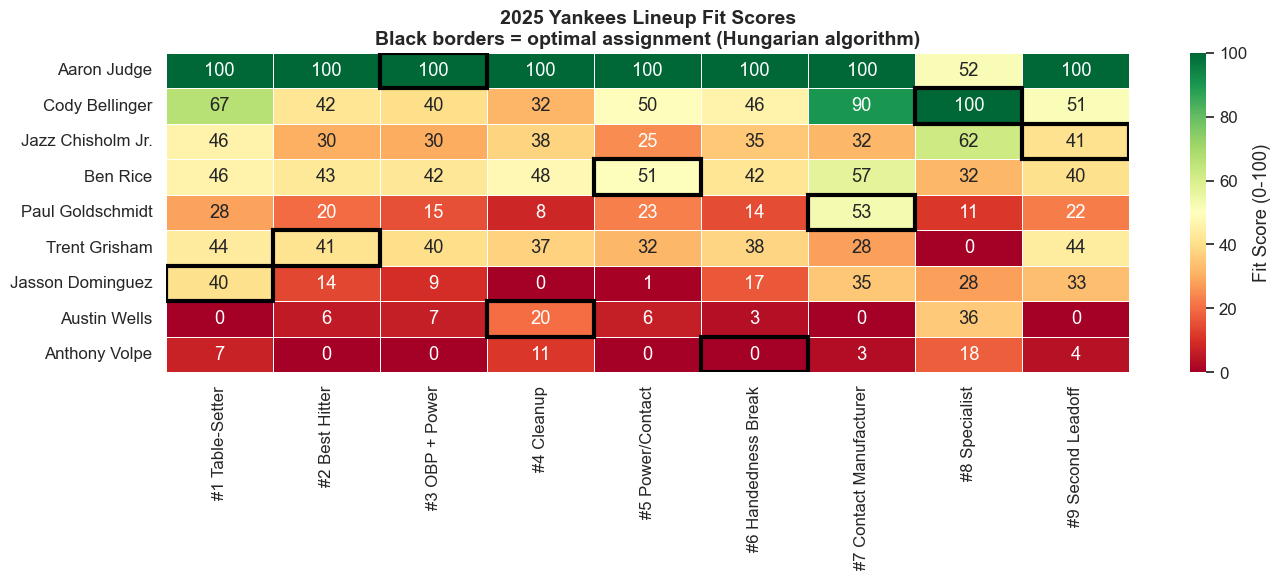

In [9]:
# Figure 1: Fit score heatmap — each Yankee vs each lineup spot
fig, ax = plt.subplots(figsize=(14, max(6, len(nyy_25_teams) * 0.6)))

# Sort players by their best fit score
spot_cols = [c for c in range(1, 10) if c in nyy_fit.columns]
plot_data = nyy_fit.set_index("Name")[spot_cols].copy()
plot_data = plot_data.loc[plot_data.max(axis=1).sort_values(ascending=False).index]

# Rename columns to lineup spot names
col_labels = [f"#{s} {LINEUP_PROFILES[s]['name']}" for s in spot_cols]
plot_data.columns = col_labels

sns.heatmap(plot_data, annot=True, fmt=".0f", cmap="RdYlGn",
            vmin=0, vmax=100, linewidths=0.5,
            cbar_kws={"label": "Fit Score (0-100)"},
            ax=ax)

# Mark optimal assignments
for _, row in assignments_df.iterrows():
    player_name = row["name"]
    spot = int(row["spot"])
    if player_name in plot_data.index:
        y_pos = list(plot_data.index).index(player_name)
        x_pos = spot - 1
        ax.add_patch(plt.Rectangle((x_pos, y_pos), 1, 1,
                                    fill=False, edgecolor="black", linewidth=3))

ax.set_title("2025 Yankees Lineup Fit Scores\nBlack borders = optimal assignment (Hungarian algorithm)",
             fontsize=14, fontweight="bold")
ax.set_ylabel("")
ax.set_xlabel("")

plt.tight_layout()
plt.savefig("../outputs/figures/yankees_lineup_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

## Part 4: Gap Analysis

Where does the 2025 Yankees roster fit the ideal model, and where are the gaps? A fit score above 70 means the player is a strong match for that spot. Below 40 means there's a significant gap — either the player doesn't exist on the roster, or the best available option is a poor fit.

In [10]:
# Gap analysis: which spots are well-filled vs gaps
print("GAP ANALYSIS: 2025 YANKEES LINEUP")
print("=" * 70)

well_filled = []
gaps = []

for _, row in assignments_df.iterrows():
    spot = int(row["spot"])
    score = row["fit_score"]
    name = row["name"]
    role = row["role"]
    
    if score >= 70:
        status = "STRONG FIT"
        well_filled.append(row)
    elif score >= 50:
        status = "ADEQUATE"
    else:
        status = "** GAP **"
        gaps.append(row)
    
    print(f"  #{spot} {role:<22} {name:<22} {score:>5.1f}  {status}")

print(f"\nStrong fits (70+): {len(well_filled)}/9")
print(f"Gaps (<50): {len(gaps)}/9")

if len(gaps) > 0:
    print(f"\nGap positions need:")
    for _, gap in pd.DataFrame(gaps).iterrows():
        spot = int(gap["spot"])
        profile = LINEUP_PROFILES[spot]
        print(f"  #{spot} {profile['name']}: {profile['description']}")
        if profile["thresholds"]:
            thresh_str = ", ".join(f"{k} {'<=' if '<' in str(v) else '>='} {v}" 
                                   for k, v in profile["thresholds"].items() if k)
            print(f"      Targets: {thresh_str}")

GAP ANALYSIS: 2025 YANKEES LINEUP
  #1 Table-Setter           Jasson Dominguez        40.4  ** GAP **
  #2 Best Hitter            Trent Grisham           41.1  ** GAP **
  #3 OBP + Power            Aaron Judge            100.0  STRONG FIT
  #4 Cleanup                Austin Wells            20.3  ** GAP **
  #5 Power/Contact          Ben Rice                50.6  ADEQUATE
  #6 Handedness Break       Anthony Volpe            0.0  ** GAP **
  #7 Contact Manufacturer   Paul Goldschmidt        52.8  ADEQUATE
  #8 Specialist             Cody Bellinger         100.0  STRONG FIT
  #9 Second Leadoff         Jazz Chisholm Jr.       40.8  ** GAP **

Strong fits (70+): 2/9
Gaps (<50): 5/9

Gap positions need:
  #1 Table-Setter: Gets on base, sees pitches, runs the bases
      Targets: OBP >= 0.34, K% >= 0.2, BB% >= 0.09
  #2 Best Hitter: Highest overall production, can drive in leadoff and get on for 3-4
      Targets: wOBA >= 0.37, OBP >= 0.37
  #4 Cleanup: Maximum damage — highest power, best ba

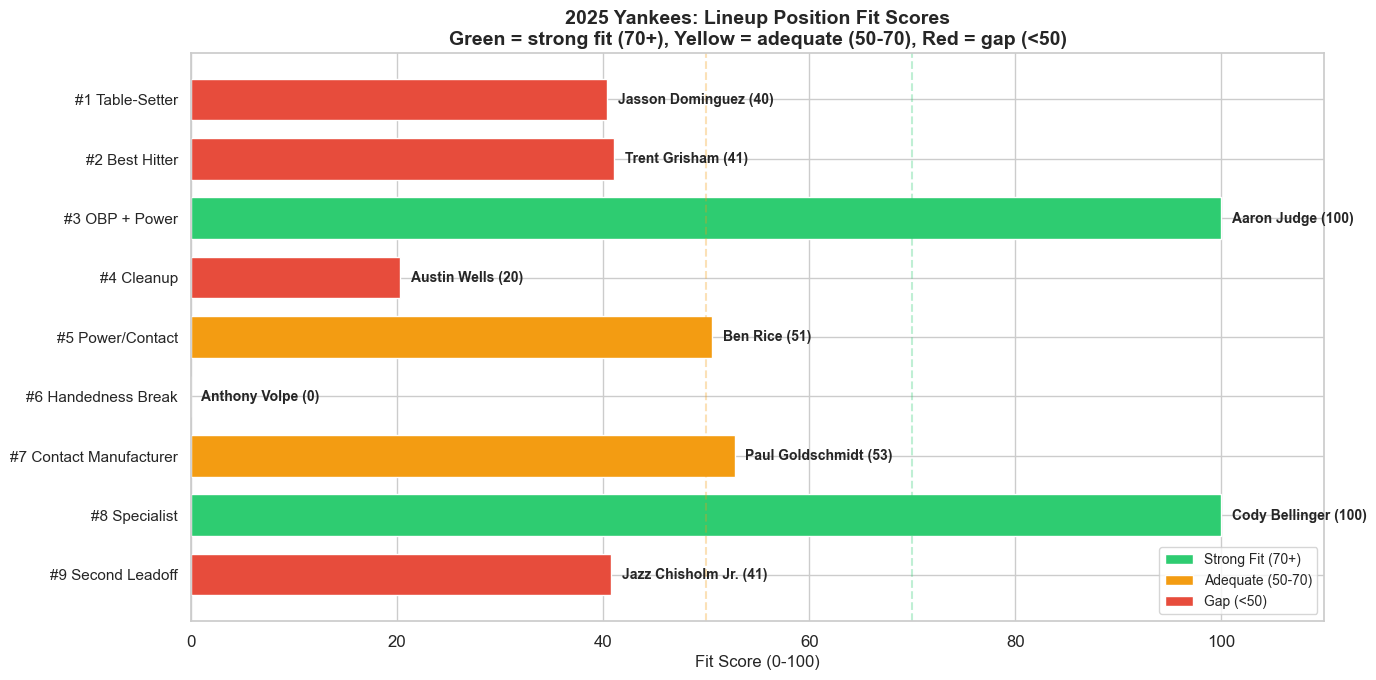

In [11]:
# Figure 2: Gap analysis bar chart
fig, ax = plt.subplots(figsize=(14, 7))

sorted_assignments = assignments_df.sort_values("spot")
spots = [f"#{int(r['spot'])} {r['role']}" for _, r in sorted_assignments.iterrows()]
scores = sorted_assignments["fit_score"].values
names = sorted_assignments["name"].values

colors = ["#2ecc71" if s >= 70 else "#f39c12" if s >= 50 else "#e74c3c" for s in scores]

bars = ax.barh(range(len(spots)), scores, color=colors, edgecolor="white", height=0.7)

# Add player names on bars
for i, (bar, name, score) in enumerate(zip(bars, names, scores)):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
            f"{name} ({score:.0f})", va="center", fontsize=10, fontweight="bold")

ax.set_yticks(range(len(spots)))
ax.set_yticklabels(spots, fontsize=11)
ax.set_xlabel("Fit Score (0-100)", fontsize=12)
ax.set_title("2025 Yankees: Lineup Position Fit Scores\nGreen = strong fit (70+), Yellow = adequate (50-70), Red = gap (<50)",
             fontsize=14, fontweight="bold")
ax.set_xlim(0, 110)
ax.axvline(70, color="#2ecc71", linestyle="--", alpha=0.3)
ax.axvline(50, color="#f39c12", linestyle="--", alpha=0.3)
ax.invert_yaxis()

# Legend
legend_elements = [
    mpatches.Patch(facecolor="#2ecc71", label="Strong Fit (70+)"),
    mpatches.Patch(facecolor="#f39c12", label="Adequate (50-70)"),
    mpatches.Patch(facecolor="#e74c3c", label="Gap (<50)"),
]
ax.legend(handles=legend_elements, loc="lower right", fontsize=10)

plt.tight_layout()
plt.savefig("../outputs/figures/yankees_lineup_gaps.png", dpi=150, bbox_inches="tight")
plt.show()

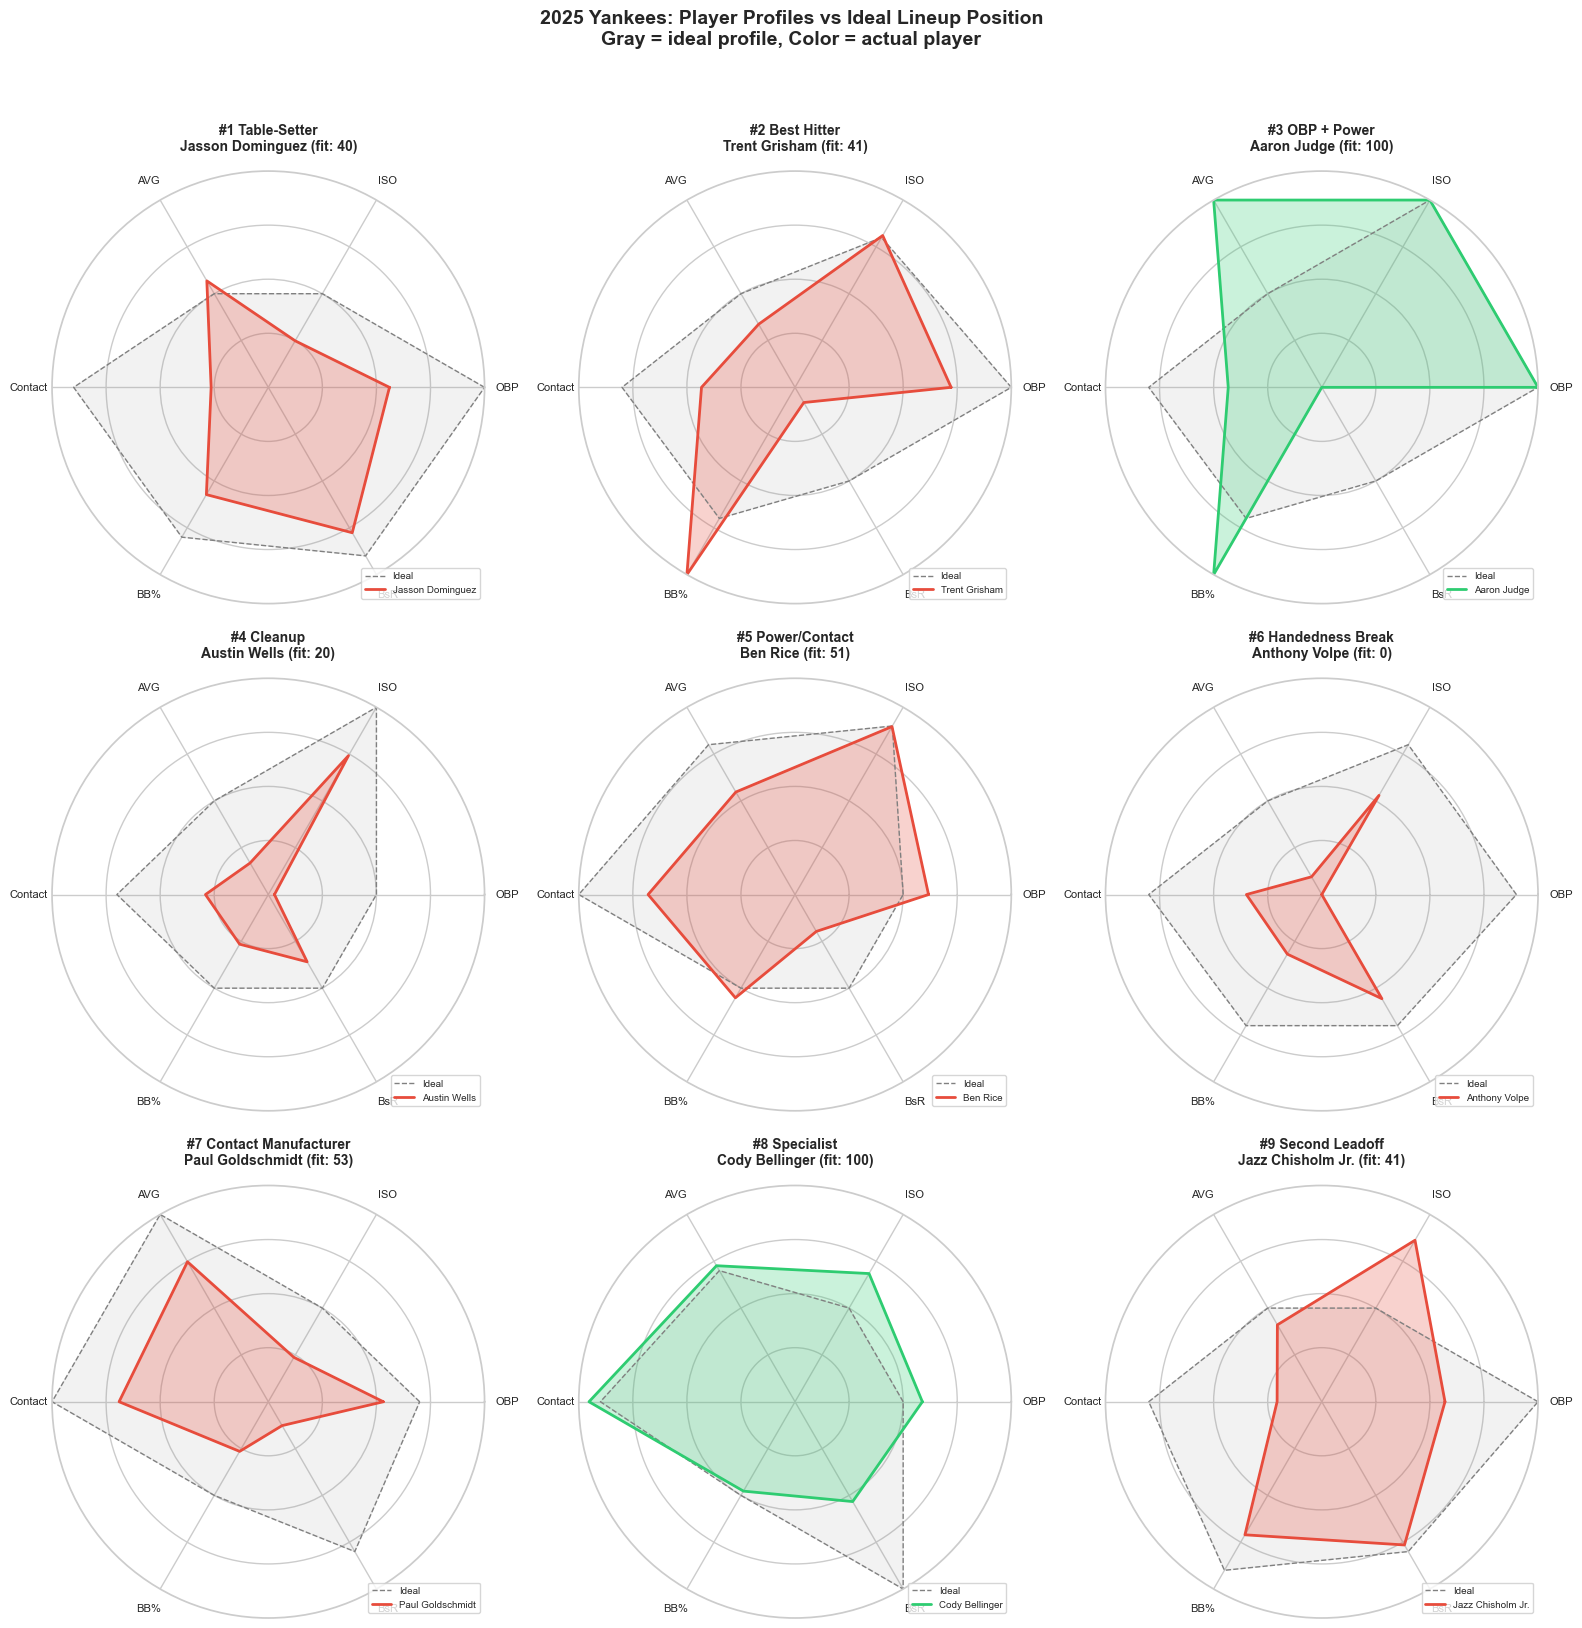

In [12]:
# Figure 3: Radar comparison — ideal profile vs actual Yankee for each spot
# Show 3x3 grid of mini-radars

radar_stats = ["OBP", "ISO", "AVG"]
if k_col:
    radar_stats.append(k_col)
if bb_col:
    radar_stats.append(bb_col)
if bsr_col and bsr_col in qualified.columns:
    radar_stats.append(bsr_col)
# Keep to 5-6 stats for readable radar
radar_stats = radar_stats[:6]

# Compute percentile ranges for normalization
stat_ranges = {}
for stat in radar_stats:
    if stat in qualified.columns:
        vals = pd.to_numeric(qualified[stat], errors="coerce").dropna()
        stat_ranges[stat] = (vals.quantile(0.05), vals.quantile(0.95))

def normalize_stat(value, stat):
    """Normalize stat to 0-1 scale based on qualified hitter range."""
    if stat not in stat_ranges or pd.isna(value):
        return 0.5
    lo, hi = stat_ranges[stat]
    if stat == k_col:  # invert — lower K% is better
        return 1 - np.clip((value - lo) / (hi - lo), 0, 1)
    return np.clip((value - lo) / (hi - lo), 0, 1)


fig, axes = plt.subplots(3, 3, figsize=(16, 16), subplot_kw=dict(polar=True))
angles = np.linspace(0, 2 * np.pi, len(radar_stats), endpoint=False).tolist()
angles += angles[:1]  # close the polygon

stat_labels = [s.replace("_", " ") for s in radar_stats]
# Rename K% label to "Contact (inv K%)" for clarity
stat_labels = ["Contact" if s == k_col else s for s in stat_labels]

for idx, (_, row) in enumerate(assignments_df.sort_values("spot").iterrows()):
    ax = axes[idx // 3][idx % 3]
    spot = int(row["spot"])
    name = row["name"]
    
    # Get player stats
    player = nyy_25_teams[nyy_25_teams["Name"] == name]
    if len(player) == 0:
        continue
    player = player.iloc[0]
    
    # Player values
    player_vals = [normalize_stat(player.get(s, np.nan), s) for s in radar_stats]
    player_vals += player_vals[:1]
    
    # Ideal values (based on weights — higher weight = higher ideal)
    profile = LINEUP_PROFILES[spot]
    ideal_vals = []
    for stat in radar_stats:
        w = profile["weights"].get(stat, 0)
        if stat == k_col:
            ideal_vals.append(0.5 + abs(w) * 2)  # want low K% = high on inverted scale
        else:
            ideal_vals.append(0.5 + w * 2)
    ideal_vals = [np.clip(v, 0, 1) for v in ideal_vals]
    ideal_vals += ideal_vals[:1]
    
    # Plot
    ax.fill(angles, ideal_vals, alpha=0.1, color="gray")
    ax.plot(angles, ideal_vals, "--", color="gray", linewidth=1, label="Ideal")
    ax.fill(angles, player_vals, alpha=0.25, color="#2ecc71" if row["fit_score"] >= 60 else "#e74c3c")
    ax.plot(angles, player_vals, "-", color="#2ecc71" if row["fit_score"] >= 60 else "#e74c3c",
            linewidth=2, label=name)
    
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(stat_labels, fontsize=8)
    ax.set_ylim(0, 1)
    ax.set_yticks([0.25, 0.5, 0.75])
    ax.set_yticklabels([])
    ax.set_title(f"#{spot} {profile['name']}\n{name} (fit: {row['fit_score']:.0f})",
                fontsize=10, fontweight="bold", pad=15)
    ax.legend(loc="lower right", fontsize=7)

plt.suptitle("2025 Yankees: Player Profiles vs Ideal Lineup Position\nGray = ideal profile, Color = actual player",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("../outputs/figures/yankees_lineup_radars.png", dpi=150, bbox_inches="tight")
plt.show()

## Part 5: Comparison — SABR Order vs Our Model

How does our model differ from the standard sabermetric lineup? Traditional SABR says: sort by wOBA, put the best at 2, highest OBP at 1, and don't worry about the rest because lineup order barely matters.

Our model says lineup order matters **at the margins** — specifically:
- Speed in the leadoff spot creates run expectancy that pure OBP misses
- Contact in the 5-7 spots protects against rally-killing K's
- Handedness alternation forces bullpen decisions
- The 9-hole is genuinely important as a second leadoff

In [13]:
# Compare our optimal lineup to a naive wOBA sort
sabr_order = nyy_25_teams.sort_values("wOBA", ascending=False).head(9).copy()
sabr_order["sabr_spot"] = range(1, len(sabr_order) + 1)
# Traditional SABR: best OBP at 1, best hitter at 2, then sort by wOBA
sabr_order = sabr_order.sort_values("OBP", ascending=False)
# Move highest OBP to 1, then re-sort rest by wOBA
leadoff = sabr_order.iloc[0:1]
rest = sabr_order.iloc[1:].sort_values("wOBA", ascending=False)
sabr_lineup = pd.concat([leadoff, rest]).reset_index(drop=True)
sabr_lineup["sabr_spot"] = range(1, len(sabr_lineup) + 1)

print("LINEUP COMPARISON: Our Model vs Traditional SABR")
print("=" * 75)
print(f"{'Spot':<6} {'Our Model':<25} {'Fit':>5}  {'SABR Order':<25} {'wOBA':>6}")
print("-" * 75)

our_lineup = assignments_df.sort_values("spot")
for i in range(min(9, len(our_lineup), len(sabr_lineup))):
    our_row = our_lineup.iloc[i]
    sabr_row = sabr_lineup.iloc[i]
    diff = "" if our_row["name"] == sabr_row["Name"] else " <<"
    print(f"  #{int(our_row['spot']):<4} {our_row['name']:<25} {our_row['fit_score']:>5.1f}  "
          f"{sabr_row['Name']:<25} {sabr_row['wOBA']:>6.3f}{diff}")

# Count differences
our_names = our_lineup["name"].tolist()
sabr_names = sabr_lineup["Name"].tolist()[:len(our_names)]
same_spot = sum(1 for a, b in zip(our_names, sabr_names) if a == b)
print(f"\nSame player in same spot: {same_spot}/{len(our_names)}")
print(f"Differences marked with <<")

LINEUP COMPARISON: Our Model vs Traditional SABR
Spot   Our Model                   Fit  SABR Order                  wOBA
---------------------------------------------------------------------------
  #1    Jasson Dominguez           40.4  Aaron Judge                0.463 <<
  #2    Trent Grisham              41.1  Ben Rice                   0.358 <<
  #3    Aaron Judge               100.0  Trent Grisham              0.353 <<
  #4    Austin Wells               20.3  Jazz Chisholm Jr.          0.349 <<
  #5    Ben Rice                   50.6  Cody Bellinger             0.347 <<
  #6    Anthony Volpe               0.0  Jasson Dominguez           0.316 <<
  #7    Paul Goldschmidt           52.8  Paul Goldschmidt           0.316
  #8    Cody Bellinger            100.0  Austin Wells               0.302 <<
  #9    Jazz Chisholm Jr.          40.8  Anthony Volpe              0.286 <<

Same player in same spot: 1/9
Differences marked with <<


## Thesis: Lineup Construction as Roster Construction

### What the model shows

The ideal lineup isn't just "sort by wOBA." Each spot has a **distinct role** that requires a specific skill mix:
- The leadoff spot needs speed + OBP, not just OBP
- The 5-hole needs contact + power, not just power
- The 7-hole needs a contact manufacturer who can move runners
- The 9-hole is a second leadoff — OBP and patience matter

### The roster construction connection

This is why **roster construction matters more than individual talent**. You can have 9 hitters with .310+ wOBA and still have a lineup full of gaps if they're all the same type. The 2017-2024 Yankees proved this: they kept acquiring one-dimensional hitters (all power or all contact) and couldn't fill the specific roles each lineup spot demands.

### Beyond traditional SABR

Traditional sabermetric lineup optimization says lineup order barely matters — maybe 10-15 runs per season. That's true in the aggregate. But our model isn't about finding 15 runs in the batting order. It's about **diagnosing what's missing from the roster** by mapping each player to what each spot needs.

A team with strong fit scores at all 9 spots has:
- A genuine leadoff catalyst (not just the highest OBP guy)
- Power distributed across multiple spots (not concentrated in 1-2 hitters)
- Contact in the middle of the order to cash in runners
- Speed and defense contributing in spots where the offensive bar is lower
- A second leadoff at 9 to turn the lineup over

That's not a batting order optimization — that's a **roster blueprint**.